In [1]:
!pip install xgboost shap optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 22.3 MB/s eta 0:00:00


In [28]:
import pandas as pd

df = pd.read_csv("urban_heat_dataset.csv")

print(df.shape)
df.head()

(1000, 8)


,system:index,ALBEDO,EVI,LST,MNDWI,NDBI,NDVI,.geo
0,0,0.204325,0.156020,27.092258,-0.282403,0.040733,0.181186,"{""type"":""Point"",""coordinates"":[77.746011353445..."
1,1,0.226400,0.118269,30.720486,-0.192521,0.024684,0.120661,"{""type"":""Point"",""coordinates"":[77.776575069258..."
2,2,0.168600,0.242639,32.364554,-0.320036,-0.051103,0.311017,"{""type"":""Point"",""coordinates"":[77.596333835972..."
3,3,0.166263,0.168853,31.935592,-0.472237,0.071200,0.251078,"{""type"":""Point"",""coordinates"":[77.775694297853..."
4,4,0.163000,0.161195,30.928985,-0.513567,0.172493,0.236459,"{""type"":""Point"",""coordinates"":[77.613280813822..."


In [30]:
print(df[".geo"].iloc[0])

{"type":"Point","coordinates":[77.746011353445,12.95570168063996]}


In [31]:
import json

def get_lon(x):
    return json.loads(x)["coordinates"][0]

def get_lat(x):
    return json.loads(x)["coordinates"][1]

df["longitude"] = df[".geo"].apply(get_lon)
df["latitude"] = df[".geo"].apply(get_lat)

df.head()

,system:index,ALBEDO,EVI,LST,MNDWI,NDBI,NDVI,.geo,longitude,latitude
0,0,0.204325,0.156020,27.092258,-0.282403,0.040733,0.181186,"{""type"":""Point"",""coordinates"":[77.746011353445...",77.746011,12.955702
1,1,0.226400,0.118269,30.720486,-0.192521,0.024684,0.120661,"{""type"":""Point"",""coordinates"":[77.776575069258...",77.776575,12.812417
2,2,0.168600,0.242639,32.364554,-0.320036,-0.051103,0.311017,"{""type"":""Point"",""coordinates"":[77.596333835972...",77.596334,12.881174
3,3,0.166263,0.168853,31.935592,-0.472237,0.071200,0.251078,"{""type"":""Point"",""coordinates"":[77.775694297853...",77.775694,12.838423
4,4,0.163000,0.161195,30.928985,-0.513567,0.172493,0.236459,"{""type"":""Point"",""coordinates"":[77.613280813822...",77.613281,13.166664


In [32]:
print(df[["longitude","latitude"]].head())

   longitude   latitude
0  77.746011  12.955702
1  77.776575  12.812417
2  77.596334  12.881174
3  77.775694  12.838423
4  77.613281  13.166664


In [33]:
features = [
    "NDVI",
    "NDBI",
    "EVI",
    "MNDWI",
    "ALBEDO",
    "longitude",
    "latitude"
]

X = df[features]

y = df["LST"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred)**0.5)

R2: 0.3139700206363937
MAE: 1.283817933726305
RMSE: 1.6792634161759787


In [36]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

print(
    importance.sort_values(
        "Importance",
        ascending=False
    )
)

     Feature  Importance
4     ALBEDO    0.259277
6   latitude    0.169706
5  longitude    0.158267
2        EVI    0.131647
1       NDBI    0.106292
0       NDVI    0.096575
3      MNDWI    0.078237


In [37]:
!pip install -q shap

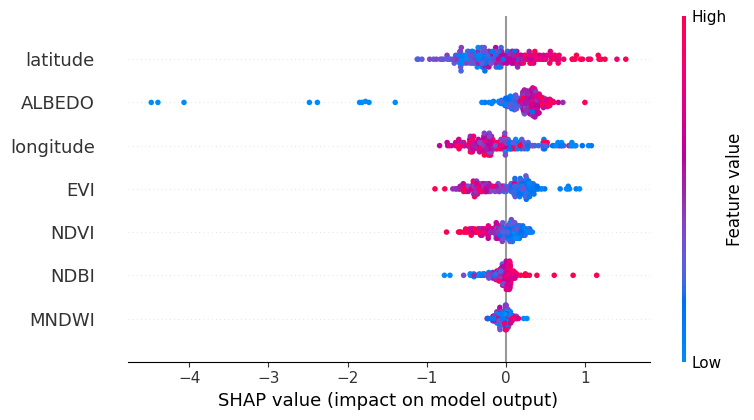

In [38]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [48]:
def simulate_cooling(
    tree_cover=0.20,
    cool_roof=0.15
):

    scenario = X.copy()

    scenario["NDVI"] = (
        scenario["NDVI"] + tree_cover*0.2
    ).clip(-1,1)

    scenario["EVI"] = (
        scenario["EVI"] + tree_cover*0.2
    ).clip(-1,1)

    scenario["ALBEDO"] = (
        scenario["ALBEDO"] + cool_roof*0.1
    ).clip(0,1)

    baseline = rf.predict(X)

    future = rf.predict(scenario)

    reduction = baseline - future

    return {
        "avg_reduction": reduction.mean(),
        "max_reduction": reduction.max(),
        "min_reduction": reduction.min()
    }

In [49]:
simulate_cooling(
    tree_cover=0.20,
    cool_roof=0.15
)

{'avg_reduction': np.float64(0.0297531975861016),
 'max_reduction': np.float64(3.0903480946798823),
 'min_reduction': np.float64(-4.55872265063984)}

In [42]:
import joblib

joblib.dump(rf, "urban_heat_rf.pkl")

['urban_heat_rf.pkl']

In [43]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print(importance)

     feature  importance
4     ALBEDO    0.259277
6   latitude    0.169706
5  longitude    0.158267
2        EVI    0.131647
1       NDBI    0.106292
0       NDVI    0.096575
3      MNDWI    0.078237


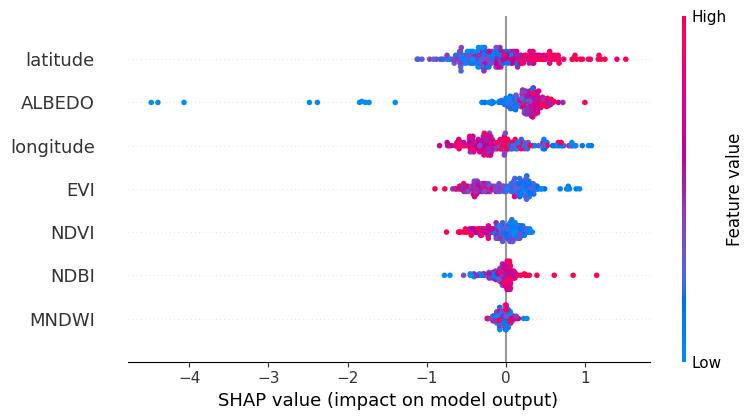

In [44]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

import matplotlib.pyplot as plt

plt.savefig(
    "shap_summary.png",
    bbox_inches="tight"
)

In [45]:
df["predicted_lst"] = rf.predict(X)

df["heat_class"] = pd.qcut(
    df["predicted_lst"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Extreme"
    ]
)

In [46]:
def simulate_intervention(
    tree_increase=0.20,
    cool_roof=0.15
):
    scenario = X.copy()

    scenario["NDVI"] *= (1 + tree_increase)
    scenario["ALBEDO"] *= (1 + cool_roof)

    baseline = rf.predict(X)
    future = rf.predict(scenario)

    reduction = baseline - future

    return {
        "avg_reduction": reduction.mean(),
        "max_reduction": reduction.max()
    }

In [47]:
simulate_intervention(
    tree_increase=0.2,
    cool_roof=0.15
)

{'avg_reduction': np.float64(-0.10218718356803838),
 'max_reduction': np.float64(1.5191184808799747)}

In [50]:
df["predicted_lst"] = rf.predict(X)

df["heat_class"] = pd.qcut(
    df["predicted_lst"],
    5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Extreme"
    ]
)

In [51]:
joblib.dump(rf, "urban_heat_rf.pkl")

df.to_csv("heat_predictions.csv", index=False)

importance.to_csv("feature_importance.csv", index=False)